In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [60]:
df=pd.read_csv('matches.csv')

In [61]:
df.head()

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,IPL-2017,Hyderabad,5/4/2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,IPL-2017,Pune,6/4/2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,IPL-2017,Rajkot,7/4/2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,IPL-2017,Indore,8/4/2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,IPL-2017,Bangalore,8/4/2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,Not Recorded,Not Recorded,NaN


In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               756 non-null    int64
 1   Season           756 non-null    str  
 2   city             756 non-null    str  
 3   date             756 non-null    str  
 4   team1            756 non-null    str  
 5   team2            756 non-null    str  
 6   toss_winner      756 non-null    str  
 7   toss_decision    756 non-null    str  
 8   result           756 non-null    str  
 9   dl_applied       756 non-null    int64
 10  winner           752 non-null    str  
 11  win_by_runs      756 non-null    int64
 12  win_by_wickets   756 non-null    int64
 13  player_of_match  752 non-null    str  
 14  venue            756 non-null    str  
 15  umpire1          756 non-null    str  
 16  umpire2          756 non-null    str  
 17  umpire3          119 non-null    str  
dtypes: int64(4), str(14)


In [63]:
print(df.shape)

(756, 18)


In [64]:
print(df.columns)

Index(['id', 'Season', 'city', 'date', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2',
       'umpire3'],
      dtype='str')


In [65]:
print(df.dtypes)

id                 int64
Season               str
city                 str
date                 str
team1                str
team2                str
toss_winner          str
toss_decision        str
result               str
dl_applied         int64
winner               str
win_by_runs        int64
win_by_wickets     int64
player_of_match      str
venue                str
umpire1              str
umpire2              str
umpire3              str
dtype: object


In [66]:
print(df.describe())

                 id  dl_applied  win_by_runs  win_by_wickets
count    756.000000  756.000000   756.000000      756.000000
mean    1792.178571    0.025132    13.283069        3.350529
std     3464.478148    0.156630    23.471144        3.387963
min        1.000000    0.000000     0.000000        0.000000
25%      189.750000    0.000000     0.000000        0.000000
50%      378.500000    0.000000     0.000000        4.000000
75%      567.250000    0.000000    19.000000        6.000000
max    11415.000000    1.000000   146.000000       10.000000


In [67]:
print(df.duplicated().sum())

0


In [68]:
print (df.nunique())

id                 756
Season              12
city                33
date               546
team1               14
team2               14
toss_winner         14
toss_decision        2
result               3
dl_applied           2
winner              14
win_by_runs         89
win_by_wickets      11
player_of_match    226
venue               41
umpire1             62
umpire2             66
umpire3             25
dtype: int64


In [69]:
matches_per_season=df.groupby('Season')['id'].count().reset_index()
matches_per_season.columns=['Season','Matches']
print(matches_per_season)

      Season  Matches
0   IPL-2008       58
1   IPL-2009       57
2   IPL-2010       60
3   IPL-2011       73
4   IPL-2012       74
5   IPL-2013       76
6   IPL-2014       60
7   IPL-2015       59
8   IPL-2016       60
9   IPL-2017       59
10  IPL-2018       60
11  IPL-2019       60


In [70]:
city_matches=(df.groupby('city')['id'].count().sort_values(ascending=False).head(10))

print(city_matches)

city
Mumbai        101
Kolkata        77
Delhi          74
Bangalore      66
Hyderabad      64
Chennai        57
Jaipur         47
Chandigarh     46
Pune           38
Durban         15
Name: id, dtype: int64


In [71]:
toss_wins=df['toss_winner'].value_counts().reset_index()
toss_wins.columns=['toss_winner','wins']
print(toss_wins)

                    toss_winner  wins
0                Mumbai Indians    98
1         Kolkata Knight Riders    92
2           Chennai Super Kings    89
3   Royal Challengers Bangalore    81
4               Kings XI Punjab    81
5              Delhi Daredevils    80
6              Rajasthan Royals    80
7           Sunrisers Hyderabad    46
8               Deccan Chargers    43
9                 Pune Warriors    20
10                Gujarat Lions    15
11       Rising Pune Supergiant    13
12               Delhi Capitals    10
13         Kochi Tuskers Kerala     8


In [72]:
decision=(df['toss_decision'].value_counts(normalize=True)*100)
print(decision)

toss_decision
field    61.243386
bat      38.756614
Name: proportion, dtype: float64


In [73]:
team_matches=pd.concat([df['team1'],df['team2']]).value_counts().reset_index()
team_matches.columns=['team','matches']
print(team_matches)

                           team  matches
0                Mumbai Indians      187
1   Royal Challengers Bangalore      180
2         Kolkata Knight Riders      178
3               Kings XI Punjab      176
4           Chennai Super Kings      164
5              Delhi Daredevils      161
6              Rajasthan Royals      147
7           Sunrisers Hyderabad      108
8               Deccan Chargers       75
9                 Pune Warriors       46
10                Gujarat Lions       30
11       Rising Pune Supergiant       30
12               Delhi Capitals       16
13         Kochi Tuskers Kerala       14


In [74]:
# Count the number of matches won by each team
team_wins = (
    df["winner"]
    .value_counts()
    .reset_index()
)

# Rename the columns
team_wins.columns = ["Team", "Wins"]

# Display the result
print(team_wins)

                           Team  Wins
0                Mumbai Indians   109
1           Chennai Super Kings   100
2         Kolkata Knight Riders    92
3   Royal Challengers Bangalore    84
4               Kings XI Punjab    82
5              Rajasthan Royals    75
6              Delhi Daredevils    67
7           Sunrisers Hyderabad    58
8               Deccan Chargers    29
9        Rising Pune Supergiant    15
10                Gujarat Lions    13
11                Pune Warriors    12
12               Delhi Capitals    10
13         Kochi Tuskers Kerala     6


In [75]:
player_awards = df['player_of_match'].value_counts().reset_index()
player_awards.columns=["player","Awards"]
print(player_awards.head(10))

           player  Awards
0        CH Gayle      21
1  AB de Villiers      20
2        MS Dhoni      17
3       DA Warner      17
4       RG Sharma      17
5       YK Pathan      16
6       SR Watson      15
7        SK Raina      14
8       G Gambhir      13
9      MEK Hussey      12


In [76]:
average_runs=df["win_by_runs"].mean()
print ("average winning margin (Runs)",average_runs)

average winning margin (Runs) 13.283068783068783


In [77]:
largest_wicket_win=df.loc[df["win_by_wickets"].idxmax()]
print(largest_wicket_win)

id                                                      3
Season                                           IPL-2017
city                                               Rajkot
date                                             7/4/2017
team1                                       Gujarat Lions
team2                               Kolkata Knight Riders
toss_winner                         Kolkata Knight Riders
toss_decision                                       field
result                                             normal
dl_applied                                              0
winner                              Kolkata Knight Riders
win_by_runs                                             0
win_by_wickets                                         10
player_of_match                                   CA Lynn
venue              Saurashtra Cricket Association Stadium
umpire1                                       Nitin Menon
umpire2                                         CK Nandan
umpire3       

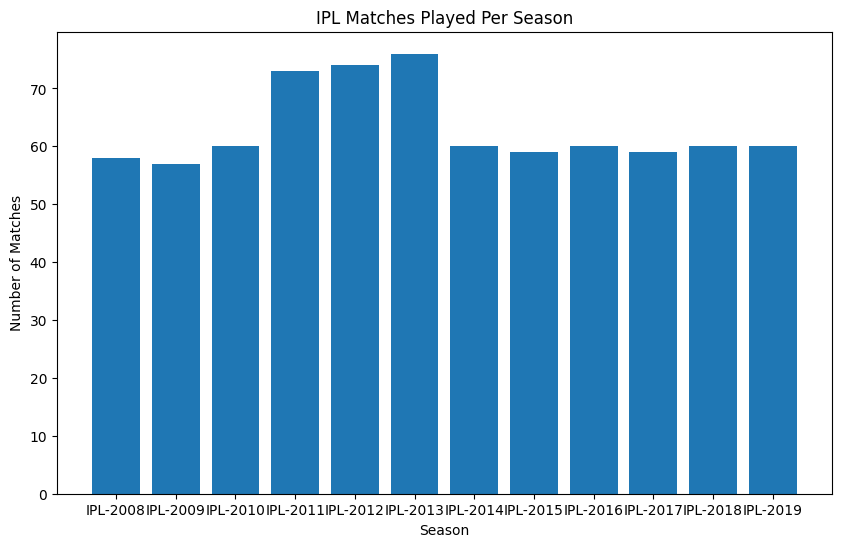

In [78]:

# Create a new figure
plt.figure(figsize=(10,6))

# Create a bar chart
plt.bar(matches_per_season["Season"], matches_per_season["Matches"])

# Add title and axis labels
plt.title("IPL Matches Played Per Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")

# Display the chart
plt.show()

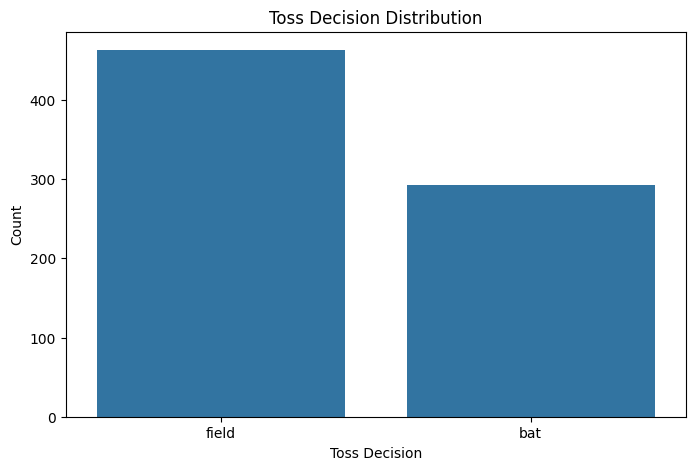

In [79]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="toss_decision")

plt.title("Toss Decision Distribution")
plt.xlabel("Toss Decision")
plt.ylabel("Count")

plt.show()


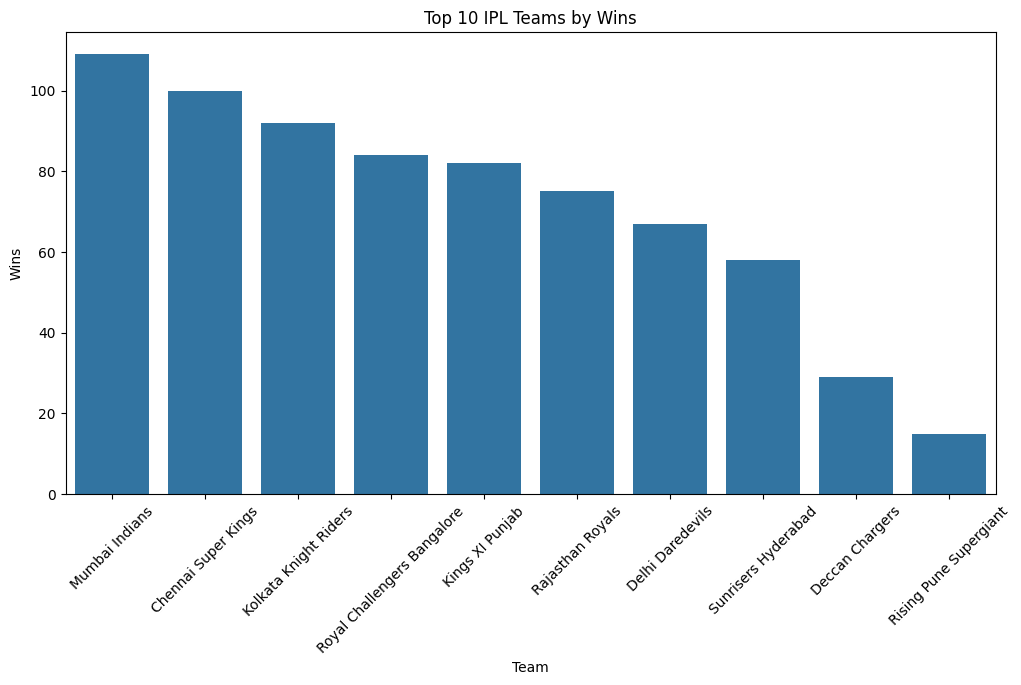

In [80]:
plt.figure(figsize=(12,6))

sns.barplot(data=team_wins.head(10), x="Team", y="Wins")

plt.title("Top 10 IPL Teams by Wins")
plt.xticks(rotation=45)

plt.show()

In [90]:
import plotly.io as pio
pio.templates.default ='plotly'

In [91]:
fig = px.bar(
    team_wins.head(10),
    x="Team",
    y="Wins",
    color="Wins",
    title="Top 10 IPL Teams by Wins"
)

fig.show()

In [92]:
decision_df = (
    df["toss_decision"]
      .value_counts()
      .reset_index()
)

decision_df.columns = ["Decision", "Count"]

fig = px.pie(
    decision_df,
    names="Decision",
    values="Count",
    title="Toss Decision Percentage"
)

fig.show()

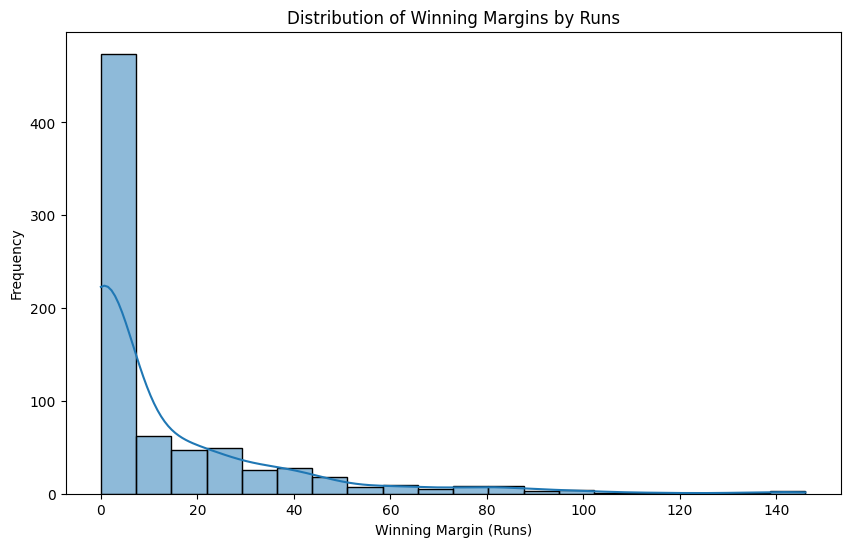

In [93]:
# Create a histogram for winning margins by runs
plt.figure(figsize=(10,6))

sns.histplot(df["win_by_runs"], bins=20, kde=True)

plt.title("Distribution of Winning Margins by Runs")
plt.xlabel("Winning Margin (Runs)")
plt.ylabel("Frequency")

plt.show()

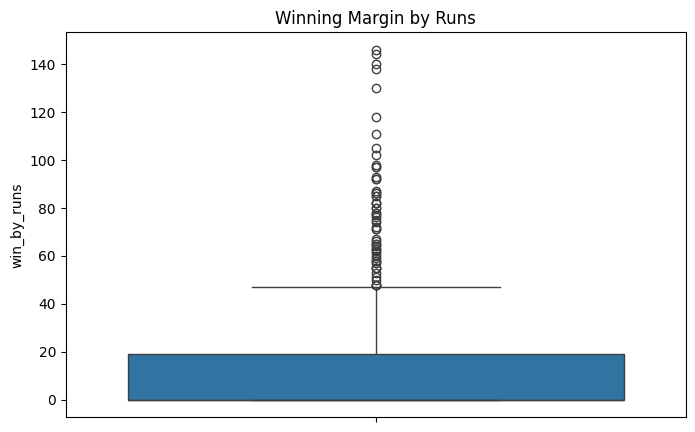

In [94]:
# Create a box plot
plt.figure(figsize=(8,5))

sns.boxplot(y=df["win_by_runs"])

plt.title("Winning Margin by Runs")

plt.show()

In [95]:
fig = px.line(
    matches_per_season,
    x="Season",
    y="Matches",
    markers=True,
    title="Matches Played Per Season"
)

fig.show()

In [96]:
fig = px.treemap(
    team_wins,
    path=["Team"],
    values="Wins",
    title="Team Wins Treemap"
)

fig.show()

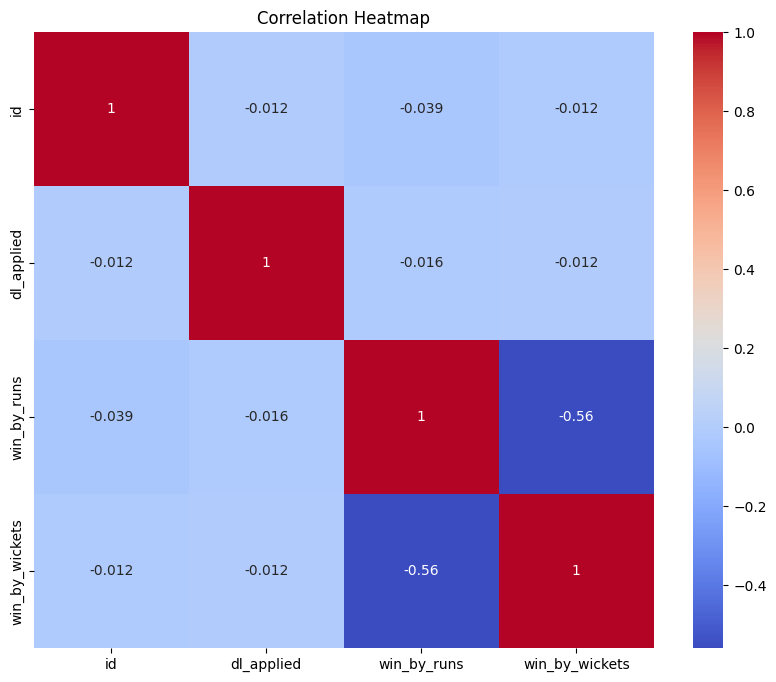

In [87]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=["number"])

# Create correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10,8))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()


